<a href="https://colab.research.google.com/github/Parigarg2006/news-aggregator-sentiment-python/blob/main/news_aggregator_sentiment_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

news-aggregator-sentiment-python

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 5.9 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=e55e9da0c43d2af727ba6239b24b1b0cd0354c8addb0076aa03fc9573310fbcb
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k

  NEWS AGGREGATOR — 08 May 2026 19:08  |  20 articles
#   Headline                                           Category     Sentiment
---------------------------------------------------------------------------
1   How I Get Free Traffic from ChatGPT in 2025 (AIO vs SEO) Technology   Positive
2   Top 10 AI Tools That Will Transform Your Content Creation in 2025 Technology   Positive
3   LimeWire AI Studio Review 2023: Details, Pricing & Features Technology   Positive
4   Top 10 AI Tools in 2023 That Will Make Your Life Easier Technology   Positive
5   Top 10 AI Content Generator & Writ

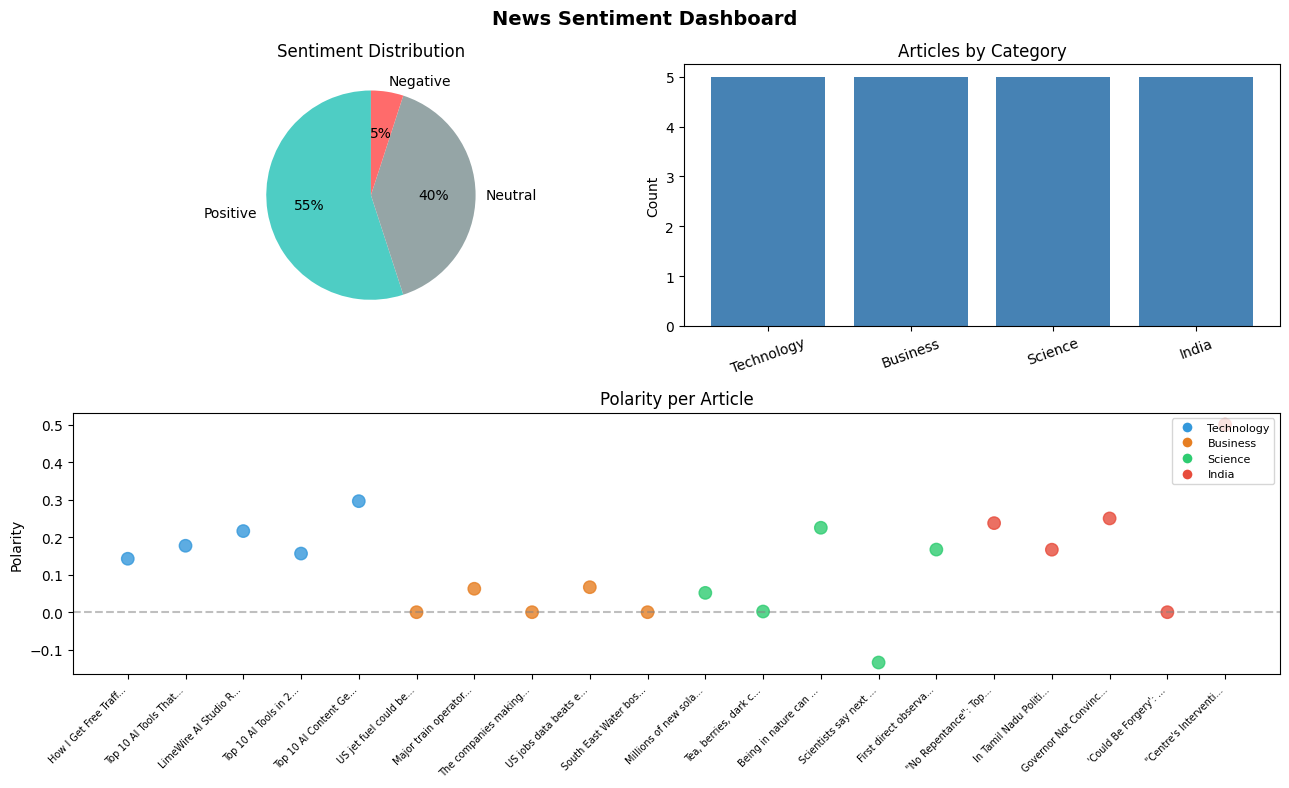

In [3]:
!pip install requests feedparser textblob matplotlib wordcloud
import feedparser
import re
import random
from datetime import datetime
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

try:
    from textblob import TextBlob
    NLP = True
except ImportError:
    NLP = False

RSS_FEEDS = {
    "Technology": "https://feeds.feedburner.com/TechCrunch",
    "Business":   "https://feeds.bbci.co.uk/news/business/rss.xml",
    "Science":    "https://rss.sciencedaily.com/top/science.xml",
    "India":      "https://feeds.feedburner.com/ndtvnews-india-news",
}

def clean_html(text):
    return re.sub(r'<[^>]+>', '', text or '').strip()

def get_sentiment(text):
    if not NLP or not text:
        return random.uniform(-0.3, 0.5), random.uniform(0.3, 0.7)
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

def sentiment_label(polarity):
    if polarity > 0.1:   return "Positive", "#4ECDC4"
    elif polarity < -0.1: return "Negative", "#FF6B6B"
    else:                  return "Neutral",  "#95A5A6"

def fetch_news(max_per_feed=5):
    all_articles = []
    for category, url in RSS_FEEDS.items():
        try:
            feed = feedparser.parse(url)
            for entry in feed.entries[:max_per_feed]:
                title = clean_html(entry.get('title', ''))
                summary = clean_html(entry.get('summary', entry.get('description', '')))
                polarity, subjectivity = get_sentiment(title + " " + summary)
                label, color = sentiment_label(polarity)
                all_articles.append({
                    "title": title[:80],
                    "category": category,
                    "published": entry.get("published", "Unknown"),
                    "link": entry.get("link", ""),
                    "polarity": polarity,
                    "subjectivity": subjectivity,
                    "sentiment": label,
                    "color": color,
                })
        except Exception as e:
            print(f"  ⚠️  Could not fetch {category}: {e}")

    if not all_articles:
        print("Using simulated news (no internet or feeds unavailable)")
        headlines = [
            ("India launches new satellite successfully", "Technology", 0.6),
            ("Stock market hits all-time high", "Business", 0.5),
            ("Scientists discover new planet", "Science", 0.7),
            ("Heavy rains cause flooding", "India", -0.4),
            ("New AI model beats human performance", "Technology", 0.4),
            ("Inflation concerns rise globally", "Business", -0.3),
            ("Breakthrough in cancer research", "Science", 0.8),
            ("Political tensions escalate", "India", -0.5),
        ]
        for title, cat, pol in headlines:
            label, color = sentiment_label(pol)
            all_articles.append({"title": title, "category": cat,
                                   "polarity": pol, "subjectivity": 0.5,
                                   "sentiment": label, "color": color,
                                   "published": datetime.now().strftime("%a, %d %b %Y")})
    return all_articles

articles = fetch_news()

# Print dashboard
print(f"\n{'='*75}")
print(f"  NEWS AGGREGATOR — {datetime.now().strftime('%d %b %Y %H:%M')}  |  {len(articles)} articles")
print(f"{'='*75}")
print(f"{'#':<3} {'Headline':<50} {'Category':<12} {'Sentiment'}")
print("-"*75)
for i, a in enumerate(articles, 1):
    print(f"{i:<3} {a['title']:<50} {a['category']:<12} {a['sentiment']}")

# Sentiment breakdown
from collections import Counter
sent_counts = Counter(a['sentiment'] for a in articles)
cat_counts = Counter(a['category'] for a in articles)
avg_polarity = sum(a['polarity'] for a in articles) / len(articles) if articles else 0
print(f"\nOverall mood: {'😊 Positive' if avg_polarity > 0 else '😞 Negative'} (avg polarity: {avg_polarity:.3f})")

# Visualization
fig = plt.figure(figsize=(13, 8))
gs = gridspec.GridSpec(2, 2)
fig.suptitle("News Sentiment Dashboard", fontsize=14, fontweight='bold')

ax1 = fig.add_subplot(gs[0,0])
colors_map = {"Positive":"#4ECDC4","Neutral":"#95A5A6","Negative":"#FF6B6B"}
ax1.pie(sent_counts.values(), labels=sent_counts.keys(),
        colors=[colors_map.get(k,'gray') for k in sent_counts.keys()],
        autopct='%1.0f%%', startangle=90)
ax1.set_title('Sentiment Distribution')

ax2 = fig.add_subplot(gs[0,1])
ax2.bar(cat_counts.keys(), cat_counts.values(), color='steelblue')
ax2.set_title('Articles by Category')
ax2.set_ylabel('Count')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=20)

ax3 = fig.add_subplot(gs[1,:])
pols = [a['polarity'] for a in articles]
cats = [a['category'] for a in articles]
c_map = {"Technology":"#3498DB","Business":"#E67E22","Science":"#2ECC71","India":"#E74C3C"}
colors_list = [c_map.get(c,'gray') for c in cats]
ax3.scatter(range(len(pols)), pols, c=colors_list, s=80, alpha=0.8)
ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax3.set_title('Polarity per Article')
ax3.set_ylabel('Polarity')
ax3.set_xticks(range(len(articles)))
ax3.set_xticklabels([a['title'][:20]+'...' for a in articles], rotation=45, ha='right', fontsize=7)
handles = [plt.Line2D([0],[0],marker='o',color='w',markerfacecolor=v,markersize=8,label=k) for k,v in c_map.items()]
ax3.legend(handles=handles, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('news_dashboard.png', dpi=150)
plt.show()